In [ ]:
##Imports & Environment Setup
import numpy as np
import pandas as pd

In [2]:
traffic = pd.read_csv("traffic_flow.csv")


In [3]:
traffic.head()


,site,day,date,start_time,end_time,flow,flow_pc,cong,cong_pc,dsat,dsat_pc,ObjectId
0,N01111A,TU,04/01/2022,2022/11/07 03:00:00+00,03:15,13,100,0,100,0,0,1
1,N01111A,TU,04/01/2022,2022/11/07 03:15:00+00,03:30,10,100,0,100,0,0,2
2,N01111A,TU,04/01/2022,2022/11/07 03:30:00+00,03:45,0,100,0,100,0,0,3
3,N01111A,TU,04/01/2022,2022/11/07 03:45:00+00,04:00,9,100,0,100,0,0,4
4,N01111A,TU,04/01/2022,2022/11/07 04:00:00+00,04:15,0,100,0,100,0,0,5


In [4]:
traffic.dtypes


site          object
day           object
date          object
start_time    object
end_time      object
flow           int64
flow_pc        int64
cong           int64
cong_pc        int64
dsat           int64
dsat_pc        int64
ObjectId       int64
dtype: object

In [ ]:
#Data Cleaning & Preprocessing
traffic=traffic.drop_duplicates()
traffic.shape

(1048575, 12)

In [6]:

traffic[['start_year','start_time']] = traffic['start_time'].str.split(' ', expand=True)
traffic.head()

,site,day,date,start_time,end_time,flow,flow_pc,cong,cong_pc,dsat,dsat_pc,ObjectId,start_year
0,N01111A,TU,04/01/2022,03:00:00+00,03:15,13,100,0,100,0,0,1,2022/11/07
1,N01111A,TU,04/01/2022,03:15:00+00,03:30,10,100,0,100,0,0,2,2022/11/07
2,N01111A,TU,04/01/2022,03:30:00+00,03:45,0,100,0,100,0,0,3,2022/11/07
3,N01111A,TU,04/01/2022,03:45:00+00,04:00,9,100,0,100,0,0,4,2022/11/07
4,N01111A,TU,04/01/2022,04:00:00+00,04:15,0,100,0,100,0,0,5,2022/11/07


In [7]:
day_map = {
    'MO': 'Monday',
    'TU': 'Tuesday',
    'WE': 'Wednesday',
    'TH': 'Thursday',
    'FR': 'Friday',
    'SA': 'Saturday',
    'SU': 'Sunday'
}

traffic['day'] = traffic['day'].map(day_map).astype('category')

In [8]:
traffic.head()

,site,day,date,start_time,end_time,flow,flow_pc,cong,cong_pc,dsat,dsat_pc,ObjectId,start_year
0,N01111A,Tuesday,04/01/2022,03:00:00+00,03:15,13,100,0,100,0,0,1,2022/11/07
1,N01111A,Tuesday,04/01/2022,03:15:00+00,03:30,10,100,0,100,0,0,2,2022/11/07
2,N01111A,Tuesday,04/01/2022,03:30:00+00,03:45,0,100,0,100,0,0,3,2022/11/07
3,N01111A,Tuesday,04/01/2022,03:45:00+00,04:00,9,100,0,100,0,0,4,2022/11/07
4,N01111A,Tuesday,04/01/2022,04:00:00+00,04:15,0,100,0,100,0,0,5,2022/11/07


In [9]:
traffic.dtypes

site            object
day           category
date            object
start_time      object
end_time        object
flow             int64
flow_pc          int64
cong             int64
cong_pc          int64
dsat             int64
dsat_pc          int64
ObjectId         int64
start_year      object
dtype: object

In [10]:
traffic['start_time']=(traffic['date'] + ' ' + traffic['start_time'])


In [11]:
traffic['start_year'].unique()

array(['2022/11/07'], dtype=object)

In [12]:
traffic.head(50)

,site,day,date,start_time,end_time,flow,flow_pc,cong,cong_pc,dsat,dsat_pc,ObjectId,start_year
0,N01111A,Tuesday,04/01/2022,04/01/2022 03:00:00+00,03:15,13,100,0,100,0,0,1,2022/11/07
1,N01111A,Tuesday,04/01/2022,04/01/2022 03:15:00+00,03:30,10,100,0,100,0,0,2,2022/11/07
2,N01111A,Tuesday,04/01/2022,04/01/2022 03:30:00+00,03:45,0,100,0,100,0,0,3,2022/11/07
3,N01111A,Tuesday,04/01/2022,04/01/2022 03:45:00+00,04:00,9,100,0,100,0,0,4,2022/11/07
4,N01111A,Tuesday,04/01/2022,04/01/2022 04:00:00+00,04:15,0,100,0,100,0,0,5,2022/11/07
5,N01111A,Tuesday,04/01/2022,04/01/2022 04:15:00+00,04:30,3,100,0,100,0,0,6,2022/11/07
6,N01111A,Tuesday,04/01/2022,04/01/2022 04:30:00+00,04:45,19,100,0,100,1,39,7,2022/11/07
7,N01111A,Tuesday,04/01/2022,04/01/2022 04:45:00+00,05:00,9,100,0,100,1,26,8,2022/11/07
8,N01111A,Tuesday,04/01/2022,04/01/2022 05:00:00+00,05:15,7,100,0,100,0,0,9,2022/11/07
9,N01111A,Tuesday,04/01/2022,04/01/2022 05:15:00+00,05:30,19,100,0,100,0,0,10,2022/11/07


In [13]:

traffic['start_time'] = pd.to_datetime(traffic['start_time'],format='mixed' , errors='coerce')

In [14]:
traffic.head()


,site,day,date,start_time,end_time,flow,flow_pc,cong,cong_pc,dsat,dsat_pc,ObjectId,start_year
0,N01111A,Tuesday,04/01/2022,2022-04-01 03:00:00+00:00,03:15,13,100,0,100,0,0,1,2022/11/07
1,N01111A,Tuesday,04/01/2022,2022-04-01 03:15:00+00:00,03:30,10,100,0,100,0,0,2,2022/11/07
2,N01111A,Tuesday,04/01/2022,2022-04-01 03:30:00+00:00,03:45,0,100,0,100,0,0,3,2022/11/07
3,N01111A,Tuesday,04/01/2022,2022-04-01 03:45:00+00:00,04:00,9,100,0,100,0,0,4,2022/11/07
4,N01111A,Tuesday,04/01/2022,2022-04-01 04:00:00+00:00,04:15,0,100,0,100,0,0,5,2022/11/07


In [15]:
traffic['end_time']=(traffic['date'] + ' ' + traffic['end_time'])

In [16]:
traffic.head()

,site,day,date,start_time,end_time,flow,flow_pc,cong,cong_pc,dsat,dsat_pc,ObjectId,start_year
0,N01111A,Tuesday,04/01/2022,2022-04-01 03:00:00+00:00,04/01/2022 03:15,13,100,0,100,0,0,1,2022/11/07
1,N01111A,Tuesday,04/01/2022,2022-04-01 03:15:00+00:00,04/01/2022 03:30,10,100,0,100,0,0,2,2022/11/07
2,N01111A,Tuesday,04/01/2022,2022-04-01 03:30:00+00:00,04/01/2022 03:45,0,100,0,100,0,0,3,2022/11/07
3,N01111A,Tuesday,04/01/2022,2022-04-01 03:45:00+00:00,04/01/2022 04:00,9,100,0,100,0,0,4,2022/11/07
4,N01111A,Tuesday,04/01/2022,2022-04-01 04:00:00+00:00,04/01/2022 04:15,0,100,0,100,0,0,5,2022/11/07


In [17]:
traffic['end_time']=pd.to_datetime(traffic['end_time'],format='mixed' , errors='coerce')


In [18]:
traffic.dtypes

site                       object
day                      category
date                       object
start_time    datetime64[ns, UTC]
end_time           datetime64[ns]
flow                        int64
flow_pc                     int64
cong                        int64
cong_pc                     int64
dsat                        int64
dsat_pc                     int64
ObjectId                    int64
start_year                 object
dtype: object

In [19]:
traffic.head()

,site,day,date,start_time,end_time,flow,flow_pc,cong,cong_pc,dsat,dsat_pc,ObjectId,start_year
0,N01111A,Tuesday,04/01/2022,2022-04-01 03:00:00+00:00,2022-04-01 03:15:00,13,100,0,100,0,0,1,2022/11/07
1,N01111A,Tuesday,04/01/2022,2022-04-01 03:15:00+00:00,2022-04-01 03:30:00,10,100,0,100,0,0,2,2022/11/07
2,N01111A,Tuesday,04/01/2022,2022-04-01 03:30:00+00:00,2022-04-01 03:45:00,0,100,0,100,0,0,3,2022/11/07
3,N01111A,Tuesday,04/01/2022,2022-04-01 03:45:00+00:00,2022-04-01 04:00:00,9,100,0,100,0,0,4,2022/11/07
4,N01111A,Tuesday,04/01/2022,2022-04-01 04:00:00+00:00,2022-04-01 04:15:00,0,100,0,100,0,0,5,2022/11/07


In [20]:
traffic["hour"] = traffic["start_time"].dt.hour


In [21]:
traffic.head()

,site,day,date,start_time,end_time,flow,flow_pc,cong,cong_pc,dsat,dsat_pc,ObjectId,start_year,hour
0,N01111A,Tuesday,04/01/2022,2022-04-01 03:00:00+00:00,2022-04-01 03:15:00,13,100,0,100,0,0,1,2022/11/07,3
1,N01111A,Tuesday,04/01/2022,2022-04-01 03:15:00+00:00,2022-04-01 03:30:00,10,100,0,100,0,0,2,2022/11/07,3
2,N01111A,Tuesday,04/01/2022,2022-04-01 03:30:00+00:00,2022-04-01 03:45:00,0,100,0,100,0,0,3,2022/11/07,3
3,N01111A,Tuesday,04/01/2022,2022-04-01 03:45:00+00:00,2022-04-01 04:00:00,9,100,0,100,0,0,4,2022/11/07,3
4,N01111A,Tuesday,04/01/2022,2022-04-01 04:00:00+00:00,2022-04-01 04:15:00,0,100,0,100,0,0,5,2022/11/07,4


In [22]:
traffic["dayofweek"] =traffic["start_time"].dt.dayofweek  # 0=Mon ... 6=Sun

In [23]:
traffic.tail()

,site,day,date,start_time,end_time,flow,flow_pc,cong,cong_pc,dsat,dsat_pc,ObjectId,start_year,hour,dayofweek
1048570,N03121D,Sunday,10/04/2022,2022-10-04 12:00:00+00:00,2022-10-04 12:15:00,132,100,0,100,59,99,1048571,2022/11/07,12,1
1048571,N03121D,Sunday,10/04/2022,2022-10-04 12:15:00+00:00,2022-10-04 12:30:00,184,100,0,100,53,98,1048572,2022/11/07,12,1
1048572,N03121D,Sunday,10/04/2022,2022-10-04 12:30:00+00:00,2022-10-04 12:45:00,116,100,0,100,46,98,1048573,2022/11/07,12,1
1048573,N03121D,Sunday,10/04/2022,2022-10-04 12:45:00+00:00,2022-10-04 13:00:00,162,100,0,100,76,98,1048574,2022/11/07,12,1
1048574,N03121D,Sunday,10/04/2022,2022-10-04 13:00:00+00:00,2022-10-04 13:15:00,181,100,0,100,78,101,1048575,2022/11/07,13,1


In [24]:
traffic.isna().sum()

site              0
day               0
date              0
start_time        0
end_time      10953
flow              0
flow_pc           0
cong              0
cong_pc           0
dsat              0
dsat_pc           0
ObjectId          0
start_year        0
hour              0
dayofweek         0
dtype: int64

In [25]:
traffic['end_time'] = pd.to_datetime(traffic['end_time'], utc=True, errors='coerce') + pd.to_timedelta(15, unit='m')

In [26]:
traffic.dropna(inplace=True)

In [27]:
traffic.tail()

,site,day,date,start_time,end_time,flow,flow_pc,cong,cong_pc,dsat,dsat_pc,ObjectId,start_year,hour,dayofweek
1048570,N03121D,Sunday,10/04/2022,2022-10-04 12:00:00+00:00,2022-10-04 12:30:00+00:00,132,100,0,100,59,99,1048571,2022/11/07,12,1
1048571,N03121D,Sunday,10/04/2022,2022-10-04 12:15:00+00:00,2022-10-04 12:45:00+00:00,184,100,0,100,53,98,1048572,2022/11/07,12,1
1048572,N03121D,Sunday,10/04/2022,2022-10-04 12:30:00+00:00,2022-10-04 13:00:00+00:00,116,100,0,100,46,98,1048573,2022/11/07,12,1
1048573,N03121D,Sunday,10/04/2022,2022-10-04 12:45:00+00:00,2022-10-04 13:15:00+00:00,162,100,0,100,76,98,1048574,2022/11/07,12,1
1048574,N03121D,Sunday,10/04/2022,2022-10-04 13:00:00+00:00,2022-10-04 13:30:00+00:00,181,100,0,100,78,101,1048575,2022/11/07,13,1


In [28]:
traffic.head()

,site,day,date,start_time,end_time,flow,flow_pc,cong,cong_pc,dsat,dsat_pc,ObjectId,start_year,hour,dayofweek
0,N01111A,Tuesday,04/01/2022,2022-04-01 03:00:00+00:00,2022-04-01 03:30:00+00:00,13,100,0,100,0,0,1,2022/11/07,3,4
1,N01111A,Tuesday,04/01/2022,2022-04-01 03:15:00+00:00,2022-04-01 03:45:00+00:00,10,100,0,100,0,0,2,2022/11/07,3,4
2,N01111A,Tuesday,04/01/2022,2022-04-01 03:30:00+00:00,2022-04-01 04:00:00+00:00,0,100,0,100,0,0,3,2022/11/07,3,4
3,N01111A,Tuesday,04/01/2022,2022-04-01 03:45:00+00:00,2022-04-01 04:15:00+00:00,9,100,0,100,0,0,4,2022/11/07,3,4
4,N01111A,Tuesday,04/01/2022,2022-04-01 04:00:00+00:00,2022-04-01 04:30:00+00:00,0,100,0,100,0,0,5,2022/11/07,4,4


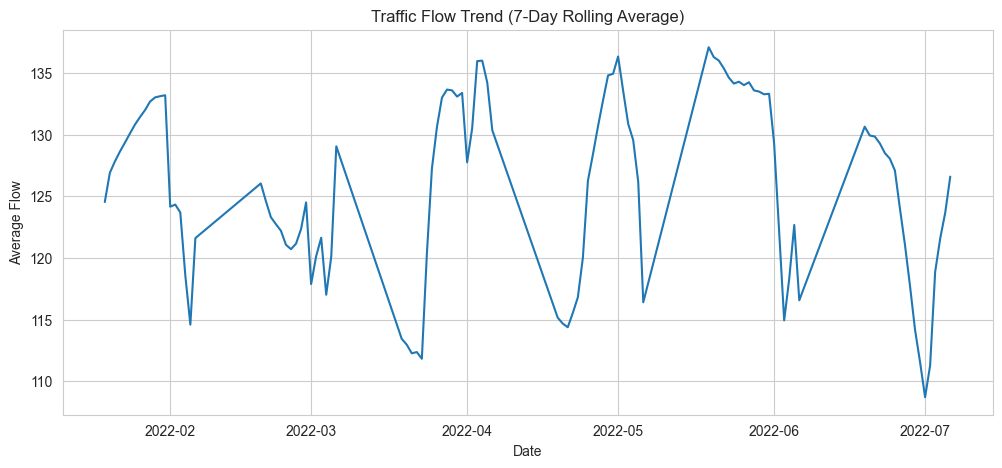

In [ ]:
# Exploratory Data Analysis (EDA) & Visualization
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")



# Sort by time (important)
traffic_sort= traffic.sort_values("start_time").set_index("start_time")
weekly = traffic_sort.select_dtypes("number").resample("D").mean()
weekly["flow_7d"] = weekly["flow"].rolling(7).mean()
weekly = weekly.reset_index()

plt.figure(figsize=(12,5))
sns.lineplot(data=weekly, x="start_time", y="flow_7d", errorbar=None)
plt.title("Traffic Flow Trend (7-Day Rolling Average)")
plt.xlabel("Date")
plt.ylabel("Average Flow")
plt.show()


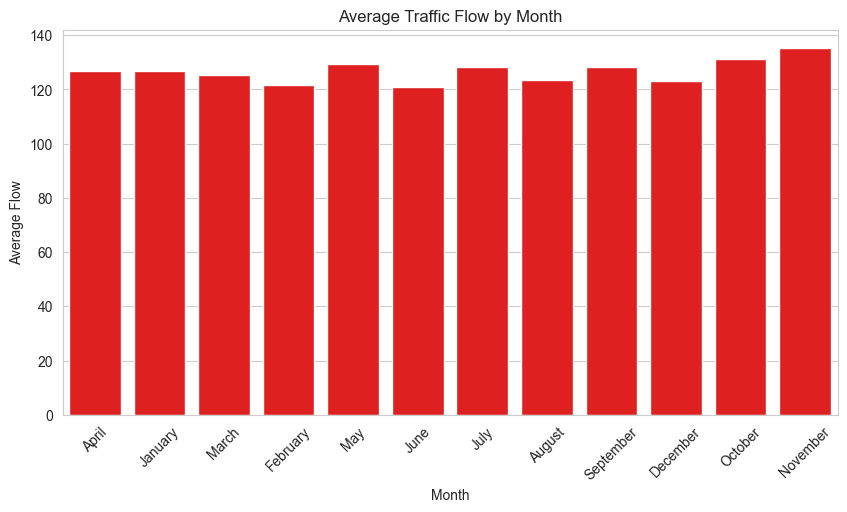

In [30]:
import matplotlib.pyplot as plt

import seaborn as sns

sns.set_style("whitegrid")

traffic['month'] = traffic['start_time'].dt.month_name()

# Ensure correct month order
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

# Plot
plt.figure(figsize=(10,5))

sns.barplot(
    data=traffic,
    x='month',
    y='flow',
    estimator='mean',   # default, but explicit is clearer
    errorbar=None,color='red'
)

plt.title("Average Traffic Flow by Month")
plt.xlabel("Month")
plt.ylabel("Average Flow")
plt.xticks(rotation=45)
plt.show()

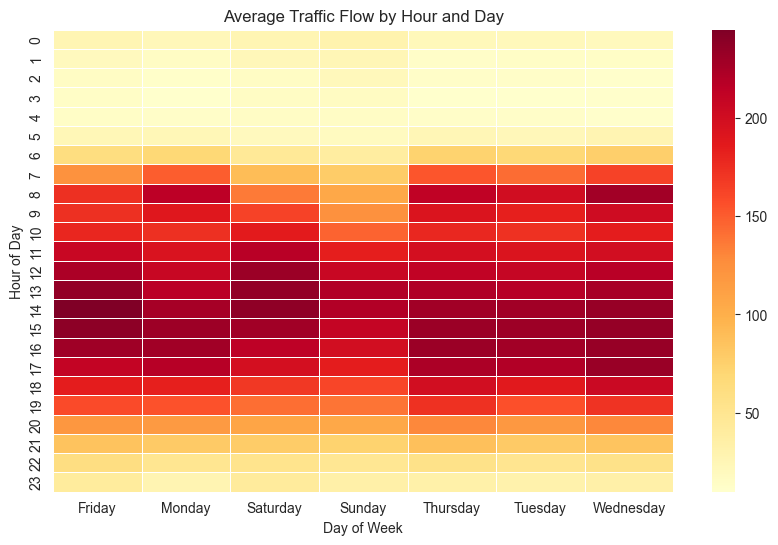

In [31]:
traffic_copy = traffic.copy()
traffic_copy["start_time"] = pd.to_datetime(traffic_copy["start_time"])
traffic_copy["hour"] = traffic_copy["start_time"].dt.hour
traffic_copy["weekday"] = traffic_copy["start_time"].dt.day_name()

pivot = traffic_copy.pivot_table(
    values="flow",
    index="hour",
    columns="weekday",
    aggfunc="mean"
)

plt.figure(figsize=(10,6))
sns.heatmap(pivot, cmap="YlOrRd",linecolor='white', linewidth=0.5)

plt.title("Average Traffic Flow by Hour and Day")
plt.xlabel("Day of Week")
plt.ylabel("Hour of Day")
plt.show()


In [32]:
x=pd.DataFrame()
y=pd.DataFrame()

In [ ]:
# Feature Engineering
for lag in range(1, 5):
    x[f'lag_{lag}'] = traffic['flow'].shift(lag)

In [34]:
x["flow_t-94"] = traffic["flow"].shift(94)
x["flow_t-95"] = traffic["flow"].shift(95)
x["flow_t-96"] = traffic["flow"].shift(96)

In [35]:
x['hour'] = traffic['hour']
x['dayofweek'] = traffic['dayofweek']

In [36]:
x['flow_t+1'] = traffic['flow'].shift(-1)   # next 15 min
x['flow_t+2'] = traffic['flow'].shift(-2)   # next 30 min
x['flow_t+3'] = traffic['flow'].shift(-3)   # next 45 min
x['flow_t+4'] = traffic['flow'].shift(-4)   # next 60 min

In [37]:
x.head()

,lag_1,lag_2,lag_3,lag_4,flow_t-94,flow_t-95,flow_t-96,hour,dayofweek,flow_t+1,flow_t+2,flow_t+3,flow_t+4
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,4,10.0,0.0,9.0,0.0
1,13.0,NaN,NaN,NaN,NaN,NaN,NaN,3,4,0.0,9.0,0.0,3.0
2,10.0,13.0,NaN,NaN,NaN,NaN,NaN,3,4,9.0,0.0,3.0,19.0
3,0.0,10.0,13.0,NaN,NaN,NaN,NaN,3,4,0.0,3.0,19.0,9.0
4,9.0,0.0,10.0,13.0,NaN,NaN,NaN,4,4,3.0,19.0,9.0,7.0


In [38]:
x.index = traffic['start_time']

In [39]:
x.isna().sum()

lag_1         1
lag_2         2
lag_3         3
lag_4         4
flow_t-94    94
flow_t-95    95
flow_t-96    96
hour          0
dayofweek     0
flow_t+1      1
flow_t+2      2
flow_t+3      3
flow_t+4      4
dtype: int64

In [40]:
x.dropna(inplace=True)

In [41]:
x.head()

,lag_1,lag_2,lag_3,lag_4,flow_t-94,flow_t-95,flow_t-96,hour,dayofweek,flow_t+1,flow_t+2,flow_t+3,flow_t+4
start_time,,,,,,,,,,,,,
2022-01-01 11:15:00+00:00,81.0,67.0,69.0,52.0,0.0,10.0,13.0,11,5,118.0,116.0,141.0,181.0
2022-01-01 11:30:00+00:00,115.0,81.0,67.0,69.0,9.0,0.0,10.0,11,5,116.0,141.0,181.0,27.0
2022-01-01 11:45:00+00:00,118.0,115.0,81.0,67.0,0.0,9.0,0.0,11,5,141.0,181.0,27.0,166.0
2022-01-01 12:00:00+00:00,116.0,118.0,115.0,81.0,3.0,0.0,9.0,12,5,181.0,27.0,166.0,180.0
2022-01-01 12:15:00+00:00,141.0,116.0,118.0,115.0,19.0,3.0,0.0,12,5,27.0,166.0,180.0,228.0


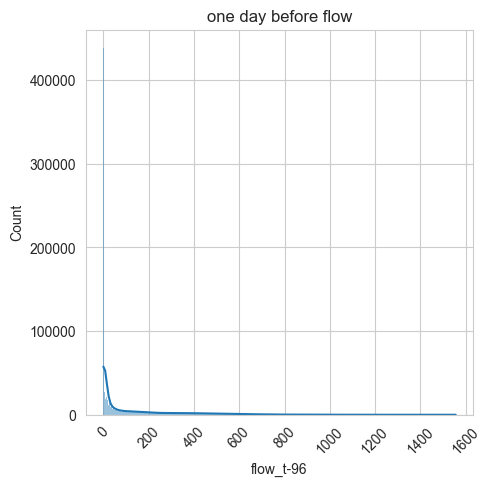

In [42]:
import matplotlib.pyplot as plt

import seaborn as sns

# Plot
plt.figure(figsize=(5,5))

sns.histplot(x['flow_t-96'], kde=True)

plt.title("one day before flow")
plt.xticks(rotation=45)
plt.show()

<Figure size 1400x800 with 0 Axes>

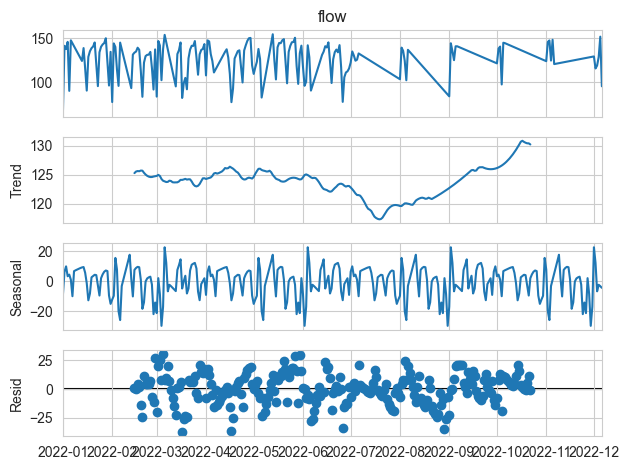

In [43]:


from statsmodels.tsa.seasonal import seasonal_decompose
flow_series = weekly.set_index('start_time')['flow'].interpolate(method='values' )
result = seasonal_decompose(flow_series, model='additive', period=90)
plt.figure(figsize=(14,8))
result.plot()
plt.show()

In [44]:
y=x[['flow_t+1', 'flow_t+2', 'flow_t+3', 'flow_t+4']]
x=x.drop(columns=['flow_t+1', 'flow_t+2', 'flow_t+3', 'flow_t+4'])

In [ ]:

#data Scaling
from sklearn.preprocessing import MinMaxScaler
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_x.fit_transform(x)
Y_scaled = scaler_y.fit_transform(y)


In [46]:
X_scaled[0:5]

array([[0.05205656, 0.04305913, 0.04434447, 0.03341902, 0.        ,
        0.00642674, 0.00835476, 0.47826087, 0.83333333],
       [0.07390746, 0.05205656, 0.04305913, 0.04434447, 0.00578406,
        0.        , 0.00642674, 0.47826087, 0.83333333],
       [0.07583548, 0.07390746, 0.05205656, 0.04305913, 0.        ,
        0.00578406, 0.        , 0.47826087, 0.83333333],
       [0.07455013, 0.07583548, 0.07390746, 0.05205656, 0.00192802,
        0.        , 0.00578406, 0.52173913, 0.83333333],
       [0.09061697, 0.07455013, 0.07583548, 0.07390746, 0.0122108 ,
        0.00192802, 0.        , 0.52173913, 0.83333333]])

In [47]:
import numpy as np
!pip install xgboost
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
#Train-Test Split

x_other,X_test, y_other, y_test = train_test_split(
	X_scaled, Y_scaled, test_size=0.2, shuffle=False
)
X_train, X_val, y_train, y_val = train_test_split(
	x_other, y_other, test_size=0.25, shuffle=False
)  # 0.25 x 0.8 = 0.2

In [ ]:
#baseline model
base_model = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model = MultiOutputRegressor(base_model)

In [50]:
model.fit(X_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,n_jobs,None
,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None


In [ ]:
# model evaluation
y_pred = model.predict(X_val)          # numpy array


In [52]:
# Reverse scaling
from sklearn.preprocessing import MinMaxScaler
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y)


y_val_inv = scaler_y.inverse_transform(y_val)
y_pred_inv = scaler_y.inverse_transform(y_pred)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse = mean_squared_error(y_val_inv, y_pred_inv)
mae = mean_absolute_error(y_val_inv, y_pred_inv)
r2 = r2_score(y_val_inv, y_pred_inv)

print("Actual MSE:", mse)
print("Actual MAE:", mae)
print("Actual R²:", r2)


Actual MSE: 13247.421597023407
Actual MAE: 52.340701848238936
Actual R²: 0.7116384734153991


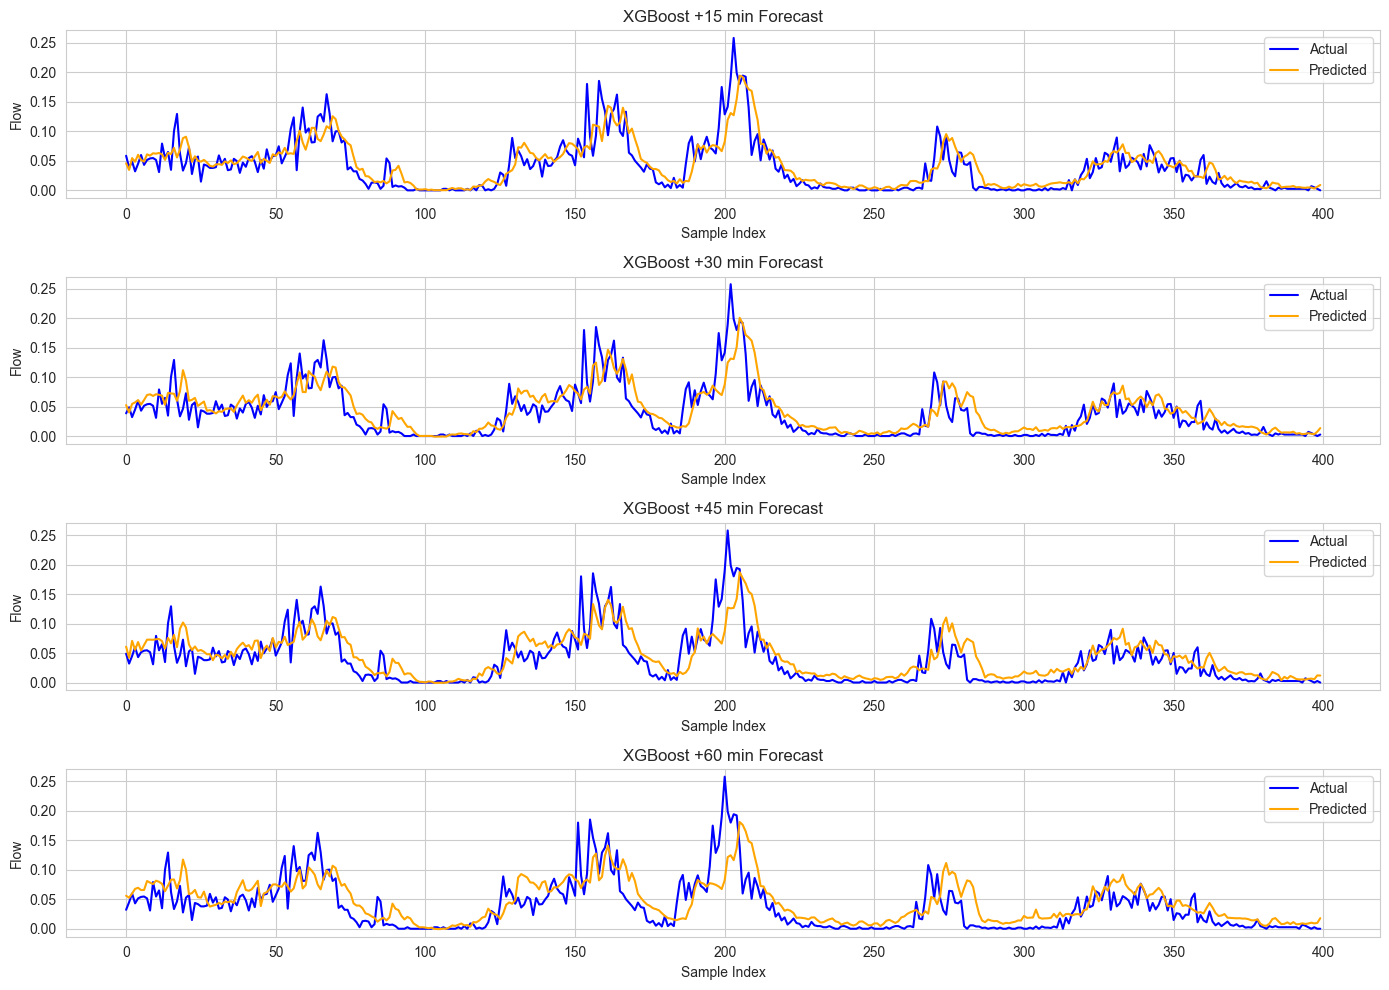

In [53]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(14,10))

target_names = ['flow_t+1', 'flow_t+2', 'flow_t+3', 'flow_t+4']
titles = [
    '+15 min Forecast',
    '+30 min Forecast',
    '+45 min Forecast',
    '+60 min Forecast'
]

# Loop through each target and create a subplot
for i, col_name in enumerate(target_names):
    plt.subplot(4, 1, i+1)   # 2 rows, 2 columns of plots

    # Access the columns by integer index 'i' for numpy arrays
    # Plotting first 500 samples for readability, similar to other plots
    plt.plot(y_val[:400, i], label='Actual', color='blue')
    plt.plot(y_pred[:400, i], label='Predicted', color='orange')

    plt.title(f'XGBoost {titles[i]}') # Added 'XGBoost' to title for clarity
    plt.xlabel('Sample Index') # Changed from 'Time' as we are plotting against sample index
    plt.ylabel('Flow')
    plt.legend()

plt.tight_layout()
plt.show()

In [54]:
import itertools

In [ ]:
# Hyperparameter Tuning 
from xgboost.callback import EarlyStopping as XGBEarlyStopping

def fit_xgb_one_horizon(Xtr, ytr, Xva, yva, params):
    """
    Train one XGBRegressor with early stopping.
    """
    model = XGBRegressor(**params)


    model.fit(
        Xtr, ytr,
        eval_set=[(Xva, yva)],
        verbose=False,

    )
    return model

def evaluate(model, Xte, yte):
    pred = model.predict(Xte)
    r2 = r2_score(yte, pred)
    mae = mean_absolute_error(yte, pred)
    rmse = np.sqrt(mean_squared_error(yte, pred))
    return r2, mae, rmse, pred




base_params = dict(
    objective="reg:squarederror",
    n_estimators=3000,        # big; early stopping chooses best trees
    min_child_weight=3,
    reg_alpha=0.0,
    reg_lambda=1.0,
    n_jobs=-1
)

learning_rates = [0.03, 0.05]
max_depths     = [4, 6]
subsamples     = [0.8, 1.0]
colsamples     = [0.8, 1.0]

history = []
best_score = -999
best_params = None

for lr, md, ss, cs in itertools.product(learning_rates, max_depths, subsamples, colsamples):
    params = base_params.copy()
    params.update({
        "learning_rate": lr,
        "max_depth": md,
        "subsample": ss,
        "colsample_bytree": cs
    })

    # Train 4 models (one per horizon) and average VALID R2
    r2_list = []
    for i, y_name in enumerate(target_names):
        m = fit_xgb_one_horizon(X_train, y_train[:, i], X_val, y_val[:, i], params)
        r2, _, _, _ = evaluate(m, X_val, y_val[:, i])
        r2_list.append(r2)

    avg_r2 = float(np.mean(r2_list))
    history.append(avg_r2)

    if avg_r2 > best_score:
        best_score = avg_r2
        best_params = params

    print(f"lr={lr}, depth={md}, subsample={ss}, colsample={cs}  --> avg VALID R2={avg_r2:.4f}")

print("\nBEST avg VALID R2:", round(best_score, 4))
print("BEST params:", best_params)

lr=0.03, depth=4, subsample=0.8, colsample=0.8  --> avg VALID R2=0.7075
lr=0.03, depth=4, subsample=0.8, colsample=1.0  --> avg VALID R2=0.7073
lr=0.03, depth=4, subsample=1.0, colsample=0.8  --> avg VALID R2=0.7100
lr=0.03, depth=4, subsample=1.0, colsample=1.0  --> avg VALID R2=0.7099
lr=0.03, depth=6, subsample=0.8, colsample=0.8  --> avg VALID R2=0.7047
lr=0.03, depth=6, subsample=0.8, colsample=1.0  --> avg VALID R2=0.7040
lr=0.03, depth=6, subsample=1.0, colsample=0.8  --> avg VALID R2=0.7069
lr=0.03, depth=6, subsample=1.0, colsample=1.0  --> avg VALID R2=0.7044
lr=0.05, depth=4, subsample=0.8, colsample=0.8  --> avg VALID R2=0.7035
lr=0.05, depth=4, subsample=0.8, colsample=1.0  --> avg VALID R2=0.7033
lr=0.05, depth=4, subsample=1.0, colsample=0.8  --> avg VALID R2=0.7074
lr=0.05, depth=4, subsample=1.0, colsample=1.0  --> avg VALID R2=0.7062
lr=0.05, depth=6, subsample=0.8, colsample=0.8  --> avg VALID R2=0.6986
lr=0.05, depth=6, subsample=0.8, colsample=1.0  --> avg VALID R2

In [57]:
# =========================
# FINAL TRAINING + TEST EVALUATION
# =========================

# Combine TRAIN + VALID sets (more data for final model)
X_train_full = np.concatenate([X_train, X_val], axis=0)
Y_train_full = np.concatenate([y_train, y_val], axis=0)

final_models = {}
vaild_report = []  

for i, y_name in enumerate(target_names):

    # Train final XGBoost model for one horizon
    model = fit_xgb_one_horizon(
        X_train_full,              # inputs (train + valid) 
        Y_train_full[:, i],        # target (train + valid)
        X_val,                     # validation inputs (for early stopping)
        y_val[:, i],               # validation targets
        best_params
    )

    # Store trained model
    final_models[y_name] = model

    # Evaluate on TEST data
    r2, mae, rmse, _ = evaluate(
        model,
        X_val,
        y_val[:, i]
    )

    vaild_report.append([y_name, mae, r2])

# Convert results to DataFrame
report_df = pd.DataFrame(
    vaild_report,
    columns=["Horizon", "TEST_MAE", "TEST_R2"]
)

print(report_df)


    Horizon  TEST_MAE   TEST_R2
0  flow_t+1  0.027321  0.793635
1  flow_t+2  0.028490  0.783505
2  flow_t+3  0.029817  0.770428
3  flow_t+4  0.031898  0.749493


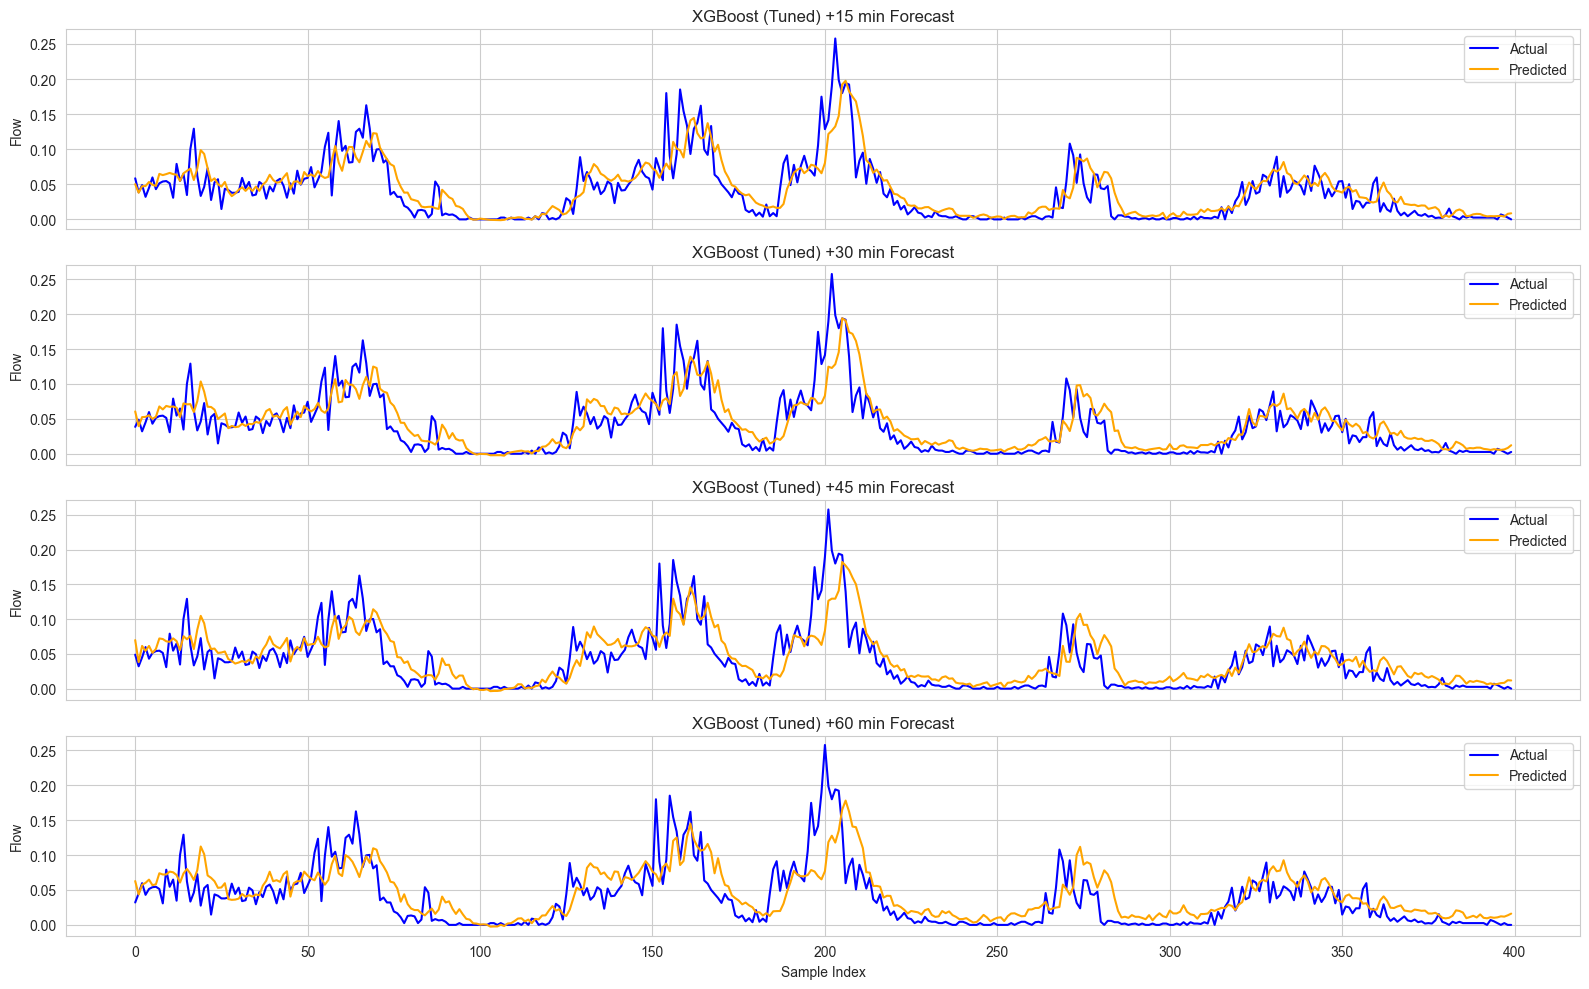

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# Corrected list of titles for display, aligning with the order of target_names
display_titles = [
    '+15 min Forecast',
    '+30 min Forecast',
    '+45 min Forecast',
    '+60 min Forecast'
]

n_plot = 400

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

# Iterate over the actual target names which are keys in final_models
for i, y_col_name in enumerate(target_names):
    # Predict using the model stored under y_col_name (e.g., 'flow_t+1')
    pred = final_models[y_col_name].predict(X_val)[:n_plot]
    # Access true values from the numpy array y_test using the index i
    true = y_val[:n_plot, i]

    axes[i].plot(true, label="Actual", color='blue')
    axes[i].plot(pred, label="Predicted", color='orange')
    axes[i].set_title(f"XGBoost (Tuned) {display_titles[i]}")
    axes[i].set_ylabel("Flow")
    axes[i].legend()

axes[-1].set_xlabel("Sample Index")
plt.tight_layout()
plt.show()

In [ ]:
-----------------------------------------------